**Data Prepossing**

In [1]:
import pandas as pd
import numpy as np
import os
import cv2
import sys
import torch
from torch.utils.data import Dataset, DataLoader
custom_module_path = os.path.join("/mnt/Main Drive/Codes/Deep Learning/Gesture_control/3D_CNN+Lstm")
sys.path.append(custom_module_path)

In [2]:
train_data = pd.read_csv('archive_2/Train.csv')
train_data.head(10)


,video_id,label,frames,label_id,shape,format
0,1,Doing other things,37,0,"(100, 176)",JPEG
1,3,Pushing Two Fingers Away,37,6,"(100, 176)",JPEG
2,6,Drumming Fingers,37,1,"(100, 176)",JPEG
3,11,Sliding Two Fingers Down,37,10,"(100, 176)",JPEG
4,14,Pushing Hand Away,37,5,"(100, 176)",JPEG
5,17,Shaking Hand,37,9,"(100, 176)",JPEG
6,20,Doing other things,37,0,"(100, 176)",JPEG
7,28,Pulling Two Fingers In,37,4,"(100, 176)",JPEG
8,31,Stop Sign,37,14,"(100, 176)",JPEG
9,34,Zooming In With Two Fingers,37,24,"(100, 176)",JPEG


In [8]:
train_data[['label', 'label_id']].value_counts().sort_index()

label                          label_id
Doing other things             0           4374
Drumming Fingers               1           1818
No gesture                     2           1844
Pulling Hand In                3           1829
Pulling Two Fingers In         4           1859
Pushing Hand Away              5           1812
Pushing Two Fingers Away       6           1843
Rolling Hand Backward          7           1715
Rolling Hand Forward           8           1788
Shaking Hand                   9           1789
Sliding Two Fingers Down       10          1832
Sliding Two Fingers Left       11          1816
Sliding Two Fingers Right      12          1780
Sliding Two Fingers Up         13          1779
Stop Sign                      14          1821
Swiping Down                   15          1824
Swiping Left                   16          1762
Swiping Right                  17          1730
Swiping Up                     18          1768
Thumb Down                     19          1810


Filter Out

In [12]:
# val_data = pd.read_csv('/mnt/Main Drive/Codes/Deep Learning/Gesture_control/3D_CNN+Lstm/archive/Validation.csv')

In [13]:
# labels_to_keep = ['Stop Sign', 'Swiping Down', 'Swiping Left', 'Swiping Right','Swiping Up','Zooming In With Two Fingers','Zooming Out With Two Fingers','No gesture']

# # Filter the DataFrame
# filtered_data = val_data[val_data['label'].isin(labels_to_keep)]

# val_data = filtered_data

# val_data['label'].value_counts().sort_index()

label
No gesture                      256
Stop Sign                       259
Swiping Down                    248
Swiping Left                    247
Swiping Right                   231
Swiping Up                      241
Zooming In With Two Fingers     257
Zooming Out With Two Fingers    261
Name: count, dtype: int64

In [14]:
# val_data['label_id'].unique()

array([15, 17, 26, 14,  2, 24, 18, 16])

In [15]:
# label_mapping = {14: 0, 24: 1, 26: 2, 2: 3, 17: 4, 16: 5, 18: 6, 15: 7}
# val_data['label_id'] = val_data['label_id'].map(label_mapping)

In [ ]:
# val_data

Moving Files

In [20]:
# import shutil

# # Directory where videos are currently stored
# folder_source_dir = 'archive/Train'

# # Directory where folders will be created
# base_dir = 'archive/train_data_labels'

# # Move each folder to its respective label folder
# for index, row in train_data.iterrows():
#     folder_id = str(row['video_id'])
#     label = row['label']
#     source_path = os.path.join(folder_source_dir, folder_id)
#     destination_path = os.path.join(base_dir, str(label), folder_id)
    
#     if os.path.exists(source_path):
#         shutil.move(source_path, destination_path)
#         print(f"Moved {folder_id} to {destination_path}")
#     else:
#         print(f"Folder {folder_id} not found in {folder_source_dir}")

# print("All folders have been moved to their respective label folders.")

Converting frames to video

In [21]:
# import cv2
# import os

# # Directory containing the frames
# frames_dir = '/mnt/Main Drive/Codes/Deep Learning/Gesture_control/3D_CNN+Lstm/archive/train_data_labels/Swiping Up/157'

# # List all frame files and sort them
# frames = sorted([os.path.join(frames_dir, frame) for frame in os.listdir(frames_dir) if frame.endswith('.jpg')])

# # Check if there are any frames
# if not frames:
# 	raise ValueError("No frames found in the directory.")

# # Read the first frame to get the dimensions
# first_frame = cv2.imread(frames[0])
# if first_frame is None:
# 	raise ValueError("The first frame could not be read.")

# height, width, layers = first_frame.shape

# # Define the codec and create VideoWriter object
# output_video = 'Swiping Up.mp4'
# fourcc = cv2.VideoWriter_fourcc(*'mp4v')  # Use 'mp4v' for .mp4 files
# video = cv2.VideoWriter(output_video, fourcc, 10, (width, height))  # Adjust FPS as needed

# # Write frames to the video
# for frame_path in frames:
# 	img = cv2.imread(frame_path)
# 	if img is None:
# 		print(f"Warning: Frame {frame_path} could not be read and will be skipped.")
# 		continue
# 	video.write(img)

# # Release the video writer
# video.release()

# print(f"Video saved as {output_video}")

Processing(2)

In [1]:
import pytorch_lightning
import pytorchvideo.data
import torch.utils.data
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image, ImageOps
from enum import Enum
import pandas as pd

from torch import randint
from pathlib import Path


/home/neutrino/miniconda3/envs/Ml/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
class JesterDataset(Dataset):
    class FrameSelectStrategy(Enum):
        FROM_BEGINNING = 0
        FROM_END = 1
        RANDOM = 2

    class FramePadding(Enum):
        REPEAT_END = 0
        REPEAT_BEGINNING = 2

    def __init__(self, csv_file, video_dir, number_of_frames, frame_file_ending="jpg",
                 frame_select_strategy=FrameSelectStrategy.RANDOM, frame_padding=FramePadding.REPEAT_END,
                 video_transform=None):
        """
        A pytorch dataset to load the 20BN-JESTER dataset or datasets in the same format.

        Args:
            csv_file: Path to the csv file, describing the videos. In jester this is eg. "1;Swipe Right" where 1 is
                the video folder name
            video_dir: Path to the directory containing the videos
            frame_file_ending: File ending of the video images, eg. "jpg" for file names like "0001.jpg"
            number_of_frames: The number of frames to get from one video.
            frame_select_strategy: When the video has more frames than number_of_frames, then the frame_select_strategy
                is used to select a subset of the frames.
            frame_padding: If the video does not have enough frames, the frame padding strategy is used to fill the frames.
            video_transform:  Videotransforms to apply to the frames. You can not use the usual torchvision.transforms
                as the same transform must be applied to all the frames of one video.
                Checkout https://github.com/hassony2/torch_videovision for video compatible transforms.

        Example:
            from jesterdataset import JesterDataset
            from torch_videovision.videotransforms.volume_transforms import ClipToTensor

            dataset = JesterDataset("./jester_data/jester-v1-train.csv", "./jester_data/20bn-jester-v1",
                                    video_transform=ClipToTensor())
            dataloader = DataLoader(dataset, batch_size=4, shuffle=True, num_workers=4)

            for i_batch, sample_batched in enumerate(dataloader):
                self.assertLessEqual(len(sample_batched), 4)
        """
        self.file_ending = frame_file_ending
        self.video_dir = video_dir
        self.number_of_frames = number_of_frames
        self.frame_select_strategy = frame_select_strategy
        self.frame_padding = frame_padding

        self.video_transform = video_transform
        self.data_description = self._read_csv(csv_file)

    def _read_csv(self, path):
        data = pd.read_csv(path)
        return data

    def __getitem__(self, index):
        # print(f"\nAccessing index: {index}")
        # print(f"\nData description row: {self.data_description.iloc[index]}")
        
        video_id, label = self.data_description.iloc[index]['video_id'], self.data_description.iloc[index]['label_id']
        video_directory = Path(self.video_dir) / str(video_id)
        frame_files = list(Path(video_directory).glob(f"*.{self.file_ending}"))
        if len(frame_files) == 0:
            raise FileNotFoundError(f"Could not find any frames. There should be at least one frame in the directory "
                                    f"{video_directory}")
        frame_files = self._add_padding(frame_files, self.number_of_frames, self.frame_padding)
        frame_files = self._select_frames(frame_files, self.frame_select_strategy, self.number_of_frames)
        frames = [Image.open(frame_file).convert('RGB') for frame_file in frame_files]
        

        if self.video_transform:
            frames = [self.video_transform(frame) for frame in frames]
        
        frames_tensor = torch.stack([transforms.ToTensor()(frame) for frame in frames])

        return frames_tensor, label

    def __len__(self):
        return len(self.data_description)

    def _add_padding(self, frame_files, number_of_frames, frame_padding: FramePadding):
        difference = number_of_frames - len(frame_files)
        if difference > 0:
            if frame_padding == self.FramePadding.REPEAT_BEGINNING:
                frame_index_to_repeat = 0
            elif frame_padding == self.FramePadding.REPEAT_END:
                frame_index_to_repeat = -1
            else:
                raise ValueError("Frame Padding Type not supported")

            frame_files += [frame_files[frame_index_to_repeat] for _ in range(difference)]

        return frame_files

    def _select_frames(self, frame_files: list, frame_select_strategy: FrameSelectStrategy, number_of_frames: int):
        if len(frame_files) <= number_of_frames:
            return frame_files
        else:
            if frame_select_strategy == self.FrameSelectStrategy.FROM_BEGINNING:
                return frame_files[:number_of_frames]
            elif frame_select_strategy == self.FrameSelectStrategy.FROM_END:
                return frame_files[-number_of_frames:]
            elif frame_select_strategy == self.FrameSelectStrategy.RANDOM:
                difference = len(frame_files) - number_of_frames
                random_start_index = randint(0, difference, (1,)).item()
                end_index = random_start_index + number_of_frames
                return frame_files[random_start_index:end_index]
            else:
                raise ValueError("FrameSelectStrategy not supported.")

In [3]:
from torch.utils.data.dataloader import DataLoader
from torchvision import transforms
from torchvideotransforms.volume_transforms import ClipToTensor

video_transform = transforms.Compose([
    # transforms.ToPILImage(),
    transforms.Resize((124, 124)),  # Resize frames to 224x224
    # transforms.ToTensor()
])

dataset_1 = JesterDataset(csv_file = "/mnt/Main Drive/Codes/Deep Learning/Gesture_control/3D_CNN+Lstm/archive/Train_aug.csv", 
video_dir = "/mnt/Main Drive/Codes/Deep Learning/Gesture_control/3D_CNN+Lstm/augmented/Train",number_of_frames = 32,
video_transform=video_transform)
train_loader = DataLoader(dataset_1, batch_size=32, shuffle=True, num_workers=8)

In [4]:
dataset_2 = JesterDataset(csv_file = "/mnt/Main Drive/Codes/Deep Learning/Gesture_control/3D_CNN+Lstm/archive/Validation_copy.csv", 
video_dir = "/mnt/Main Drive/Codes/Deep Learning/Gesture_control/3D_CNN+Lstm/archive/Val",number_of_frames = 32,
video_transform=video_transform)
val_loader = DataLoader(dataset_2, batch_size=32, shuffle=True, num_workers=8)

In [5]:
# Iterate through the dataloader
for i_batch, sample_batched in enumerate(train_loader):
    batch, label = sample_batched
    print(f"\nBatch number {i_batch} has a batch size of {len(batch)}")
    print(f"Batch type: {type(batch)}")
    
    # Print the shape of the batch tensor
    print(f"Batch shape: {batch.shape}")
    
    # Assuming batch is of shape (batch_size, num_frames, channels, height, width)
    batch_size, num_frames, channels, height, width = batch.shape
    for i in range(batch_size):
        print(f"Shape of video {i}: {batch[i].shape}")
    
    print(f"Labels: {label}")


Batch number 0 has a batch size of 32
Batch type: <class 'torch.Tensor'>
Batch shape: torch.Size([32, 32, 3, 124, 124])
Shape of video 0: torch.Size([32, 3, 124, 124])
Shape of video 1: torch.Size([32, 3, 124, 124])
Shape of video 2: torch.Size([32, 3, 124, 124])
Shape of video 3: torch.Size([32, 3, 124, 124])
Shape of video 4: torch.Size([32, 3, 124, 124])
Shape of video 5: torch.Size([32, 3, 124, 124])
Shape of video 6: torch.Size([32, 3, 124, 124])
Shape of video 7: torch.Size([32, 3, 124, 124])
Shape of video 8: torch.Size([32, 3, 124, 124])
Shape of video 9: torch.Size([32, 3, 124, 124])
Shape of video 10: torch.Size([32, 3, 124, 124])
Shape of video 11: torch.Size([32, 3, 124, 124])
Shape of video 12: torch.Size([32, 3, 124, 124])
Shape of video 13: torch.Size([32, 3, 124, 124])
Shape of video 14: torch.Size([32, 3, 124, 124])
Shape of video 15: torch.Size([32, 3, 124, 124])
Shape of video 16: torch.Size([32, 3, 124, 124])
Shape of video 17: torch.Size([32, 3, 124, 124])
Shape o

In [6]:
# Iterate through the dataloader
for i_batch, sample_batched in enumerate(val_loader):
    batch, label = sample_batched
    print(f"\nBatch number {i_batch} has a batch size of {len(batch)}")
    print(f"Batch type: {type(batch)}")
    
    # Print the shape of the batch tensor
    print(f"Batch shape: {batch.shape}")
    
    # Assuming batch is of shape (batch_size, num_frames, channels, height, width)
    batch_size, num_frames, channels, height, width = batch.shape
    for i in range(batch_size):
        print(f"Shape of video {i}: {batch[i].shape}")
    
    print(f"Labels: {label}")


Batch number 0 has a batch size of 32
Batch type: <class 'torch.Tensor'>
Batch shape: torch.Size([32, 32, 3, 124, 124])
Shape of video 0: torch.Size([32, 3, 124, 124])
Shape of video 1: torch.Size([32, 3, 124, 124])
Shape of video 2: torch.Size([32, 3, 124, 124])
Shape of video 3: torch.Size([32, 3, 124, 124])
Shape of video 4: torch.Size([32, 3, 124, 124])
Shape of video 5: torch.Size([32, 3, 124, 124])
Shape of video 6: torch.Size([32, 3, 124, 124])
Shape of video 7: torch.Size([32, 3, 124, 124])
Shape of video 8: torch.Size([32, 3, 124, 124])
Shape of video 9: torch.Size([32, 3, 124, 124])
Shape of video 10: torch.Size([32, 3, 124, 124])
Shape of video 11: torch.Size([32, 3, 124, 124])
Shape of video 12: torch.Size([32, 3, 124, 124])
Shape of video 13: torch.Size([32, 3, 124, 124])
Shape of video 14: torch.Size([32, 3, 124, 124])
Shape of video 15: torch.Size([32, 3, 124, 124])
Shape of video 16: torch.Size([32, 3, 124, 124])
Shape of video 17: torch.Size([32, 3, 124, 124])
Shape o

**Pytorch**

In [7]:
import torch
from torch import nn
import torch.nn.functional as F
from torch.optim import Adam
import sklearn
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import TensorDataset, DataLoader
from torch.utils.checkpoint import checkpoint
from sklearn.preprocessing import OneHotEncoder

# Define model
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv3d_1 = nn.Conv3d(3, 32, (3, 3, 3), stride=(1, 2, 2),padding=1)
        self.pool_1 = nn.MaxPool3d((1, 2, 2), stride=(1, 2, 2))
        self.conv3d_2 = nn.Conv3d(32, 64, (3, 3, 3),padding=1)
        self.pool_2 = nn.MaxPool3d((2, 2, 2), stride=(2, 2, 2))
        self.conv3d_3a = nn.Conv3d(64, 128, (3, 3, 3),padding=1)
        self.conv3d_3b = nn.Conv3d(128, 128, (3, 3, 3),padding=1)
        self.pool_3 = nn.MaxPool3d((2, 2, 2), stride=(2, 2, 2))
        self.conv3d_4a = nn.Conv3d(128, 128, (3, 3, 3),padding=1)
        self.conv3d_4b = nn.Conv3d(128, 128, (3, 3, 3),padding=1)
        self.pool_4 = nn.MaxPool3d((2, 2, 2), stride=(2, 2, 2))
        self.lstm = nn.LSTM(128, 128, batch_first=True)
        self.dropout = nn.Dropout(0.25)
        self.fc = nn.Linear(128, 8)
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        # print(f"Input shape: {x.shape}")
        x = self.pool_1(F.relu(self.conv3d_1(x)))
        # print(f"After conv3d_1 and pool_1: {x.shape}")
        x = self.pool_2(F.relu(self.conv3d_2(x)))
        # print(f"After conv3d_2 and pool_2: {x.shape}")
        x = F.relu(self.conv3d_3a(x))
        # print(f"After conv3d_3a: {x.shape}")
        x = self.pool_3(F.relu(self.conv3d_3b(x)))
        # print(f"After conv3d_3b and pool_3: {x.shape}")
        x = F.relu(self.conv3d_4a(x))
        # print(f"After conv3d_4a: {x.shape}")
        x = self.pool_4(F.relu(self.conv3d_4b(x)))
        # print(f"After conv3d_4b and pool_4: {x.shape}")
        x = F.normalize(x, p=2, dim=1)  # Apply L2 normalization
        x = x.view(x.size(0), -1, 128)  # Flatten layer
        # print(f"After flattening: {x.shape}")
        x, _ = self.lstm(x)
        # print(f"After LSTM: {x.shape}")
        x = self.dropout(x)
        x = self.fc(x[:, -1, :])  # Apply fully connected layer to the last time step
        x = self.softmax(x)
        # print(f"Output shape: {x.shape}")
        return x

model = Net()

In [8]:
for name, param in model.named_parameters():
    print(name, param.shape)            

conv3d_1.weight torch.Size([32, 3, 3, 3, 3])
conv3d_1.bias torch.Size([32])
conv3d_2.weight torch.Size([64, 32, 3, 3, 3])
conv3d_2.bias torch.Size([64])
conv3d_3a.weight torch.Size([128, 64, 3, 3, 3])
conv3d_3a.bias torch.Size([128])
conv3d_3b.weight torch.Size([128, 128, 3, 3, 3])
conv3d_3b.bias torch.Size([128])
conv3d_4a.weight torch.Size([128, 128, 3, 3, 3])
conv3d_4a.bias torch.Size([128])
conv3d_4b.weight torch.Size([128, 128, 3, 3, 3])
conv3d_4b.bias torch.Size([128])
lstm.weight_ih_l0 torch.Size([512, 128])
lstm.weight_hh_l0 torch.Size([512, 128])
lstm.bias_ih_l0 torch.Size([512])
lstm.bias_hh_l0 torch.Size([512])
fc.weight torch.Size([8, 128])
fc.bias torch.Size([8])


Checkpoint loaded from /mnt/Main Drive/Codes/Deep Learning/Gesture_control/3D_CNN+Lstm/checkpoints/checkpoint_epoch_10.pth
Epoch [10/50], Batch [10/2700], Loss: 1.3366
Epoch [10/50], Batch [1010/2700], Loss: 1.4303
Epoch [10/50], Batch [2010/2700], Loss: 1.4001
Epoch 10, Loss: 1.3826, Accuracy: 0.8915, Time: 1789.48s
Checkpoint saved at /mnt/Main Drive/Codes/Deep Learning/Gesture_control/3D_CNN+Lstm/checkpoints/checkpoint_epoch_10.pth
Validation Loss: 1.3643, Validation Accuracy: 0.9110
Epoch [11/50], Batch [10/2700], Loss: 1.4640
Epoch [11/50], Batch [1010/2700], Loss: 1.3474
Epoch [11/50], Batch [2010/2700], Loss: 1.4244
Epoch 11, Loss: 1.3723, Accuracy: 0.9015, Time: 1510.54s
Validation Loss: 1.3657, Validation Accuracy: 0.9070
Epoch [12/50], Batch [10/2700], Loss: 1.3676
Epoch [12/50], Batch [1010/2700], Loss: 1.5000
Epoch [12/50], Batch [2010/2700], Loss: 1.3409
Epoch 12, Loss: 1.3697, Accuracy: 0.9042, Time: 1511.09s
Validation Loss: 1.3577, Validation Accuracy: 0.9180
Epoch [13/

ValueError: x and y must have same first dimension, but have shapes (50,) and (41,)

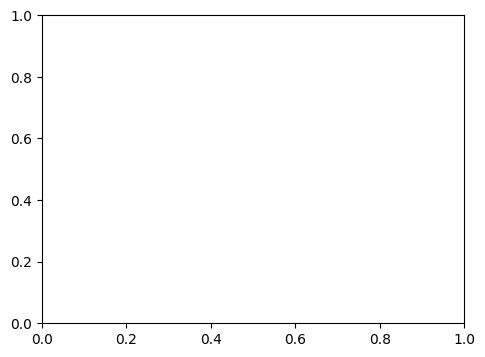

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import time
import os
import matplotlib.pyplot as plt

os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

# Assuming model is already defined
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

optimizer = torch.optim.Adam(model.parameters())
criterion = nn.CrossEntropyLoss()
num_epochs = 50  # Total number of epochs
checkpoint_dir = '/mnt/Main Drive/Codes/Deep Learning/Gesture_control/3D_CNN+Lstm/checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)

def save_checkpoint(epoch, model, optimizer, loss, accuracy, checkpoint_dir):
    checkpoint_path = os.path.join(checkpoint_dir, f'checkpoint_epoch_{epoch+1}.pth')
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss,
        'accuracy': accuracy
    }, checkpoint_path)
    print(f'Checkpoint saved at {checkpoint_path}')

def load_checkpoint(checkpoint_path, model, optimizer):
    checkpoint = torch.load(checkpoint_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    epoch = checkpoint['epoch']
    loss = checkpoint['loss']
    accuracy = checkpoint['accuracy']
    print(f'Checkpoint loaded from {checkpoint_path}')
    return epoch, loss, accuracy

# Load checkpoint from epoch 10
start_epoch = 10
checkpoint_path = os.path.join(checkpoint_dir, f'checkpoint_epoch_{start_epoch}.pth')
if os.path.exists(checkpoint_path):
    start_epoch, _, _ = load_checkpoint(checkpoint_path, model, optimizer)
else:
    start_epoch = 0

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

for epoch in range(start_epoch, num_epochs):  # Start from the loaded epoch
    model.train()
    running_loss = 0.0
    correct_predictions = 0
    total_predictions = 0
    start_time = time.time()
    
    for i, (inputs, labels) in enumerate(train_loader):
        # Check the shape of the input tensor
        # print(f"Original input shape: {inputs.shape}")
        
        # Permute the dimensions if necessary
        if inputs.shape[1] == 32:  # Assuming 32 is the number of channels
            inputs = inputs.permute(0, 2, 1, 3, 4)  # Change shape to [batch_size, channels, num_frames, height, width]
        
        inputs = inputs.to(device)  # Move inputs to GPU
        labels = labels.to(device)  # Move labels to GPU
        # print("labels: ",labels)
        # print("Inputs: ",inputs)

        optimizer.zero_grad()
        outputs = model(inputs)
   
        # Debugging prints
        # print(f"Outputs shape: {outputs.shape}")
        # print(f"Labels shape: {labels.shape}")

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        
        # Calculate accuracy
        predicted = torch.argmax(outputs, 1)
        correct_predictions += (predicted == labels).sum().item()
        total_predictions += labels.size(0)
        
        if i % 1000 == 9:  # Print every 1000 batches
            print(f'Epoch [{epoch+1}/{num_epochs}], Batch [{i+1}/{len(train_loader)}], Loss: {loss.item():.4f}')
    
    epoch_time = time.time() - start_time
    epoch_accuracy = correct_predictions / total_predictions
    train_losses.append(running_loss / len(train_loader))
    train_accuracies.append(epoch_accuracy)

    print("=======================================================")
    print(f'Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.4f}, Accuracy: {epoch_accuracy:.4f}, Time: {epoch_time:.2f}s')
    print("=======================================================")

    # Save checkpoint every 5 epochs
    if (epoch + 1) % 5 == 0:
        save_checkpoint(epoch, model, optimizer, running_loss/len(train_loader), epoch_accuracy, checkpoint_dir)

    # Validation
    model.eval()
    val_loss = 0.0
    correct_predictions = 0
    total_predictions = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            # Check the shape of the input tensor
            # print(f"Original input shape: {inputs.shape}")
            
            # Permute the dimensions if necessary
            if inputs.shape[1] == 32:  # Assuming 32 is the number of channels
                inputs = inputs.permute(0, 2, 1, 3, 4)  # Change shape to [batch_size, channels, num_frames, height, width]
            
            inputs = inputs.to(device)  # Move inputs to GPU
            labels = labels.to(device)  # Move labels to GPU if already tensor
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            
            # Calculate accuracy
            predicted = torch.argmax(outputs, 1)
            correct_predictions += (predicted == labels).sum().item()
            total_predictions += labels.size(0)
    
    val_accuracy = correct_predictions / total_predictions
    val_losses.append(val_loss / len(val_loader))
    val_accuracies.append(val_accuracy)

    print("=============================================================")
    print(f'Validation Loss: {val_loss/len(val_loader):.4f}, Validation Accuracy: {val_accuracy:.4f}')
    print("=============================================================")

0

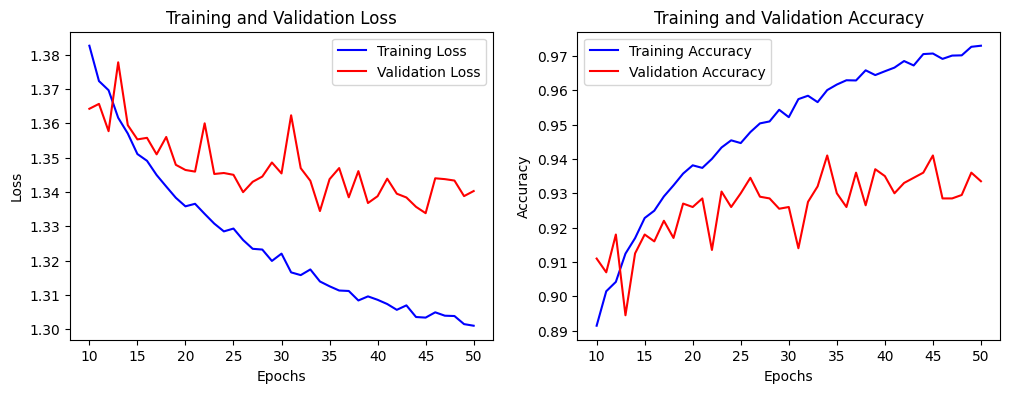

In [10]:
# Plotting the graphs
epochs = range(10, num_epochs + 1)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, 'b', label='Training Loss')
plt.plot(epochs, val_losses, 'r', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, 'b', label='Training Accuracy')
plt.plot(epochs, val_accuracies, 'r', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [11]:
def save_full_model(epoch, model, optimizer, loss, accuracy, checkpoint_dir):
    checkpoint_path = os.path.join(checkpoint_dir, f'full_model_epoch_50 Without aug.pth')
    torch.save({
        'epoch': epoch,
        'model': model,
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss,
        'accuracy': accuracy
    }, checkpoint_path)
    print(f'Full model saved at {checkpoint_path}')

In [12]:

save_full_model(epoch, model, optimizer, running_loss/len(train_loader), epoch_accuracy, checkpoint_dir)


Full model saved at /mnt/Main Drive/Codes/Deep Learning/Gesture_control/3D_CNN+Lstm/checkpoints/full_model_epoch_50 Without aug.pth
